# Setup and download data

This tutorials shows how to set up an multiple slide Alzheimer Disease Visium dataset from [Chen et al., 2022](https://pubmed.ncbi.nlm.nih.gov/36544231/). To follow along with this and the following tutorials, please execute the following steps first:

- Set up InterScale environment (see instructions in ReadMe)
- Load raw data from GEO accession (GSE220442) with [SpatialData loader](https://spatialdata.scverse.org/projects/io/en/latest/generated/spatialdata_io.visium.html).

In [5]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'
DATA = "melton25"

LRZ cluster


In [6]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import seaborn as sns

from pathlib import Path

In [7]:
from pathlib import Path
import sys

# set INTERSCALE_DIR to the current working directory
INTERSCALE_DIR = Path.cwd()
print(INTERSCALE_DIR)
project_root = Path(f'{BASE_DIR_REPO}/InterScale_reproducibility')
print(project_root)
sys.path.insert(0, str(project_root))

/workspace
/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility


In [8]:
from src.sliding_window import sliding_window

<mark>TODO: Change data path</mark>

In [20]:
CHEN_22 = os.path.join(BASE_DIR_PROJECT, 'data/chen_adata.h5ad')

## Load data

In [21]:
adata = sc.read_h5ad(CHEN_22)
adata

AnnData object with n_obs × n_vars = 25293 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region', 'patient_id', 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'category', 'stage', 'patientID', 'Layer', 'seurat_clusters', 'integrated_snn_res.0.17'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'Layer_colors', 'spatial', 'spatialdata_attrs'
    obsm: 'spatial'

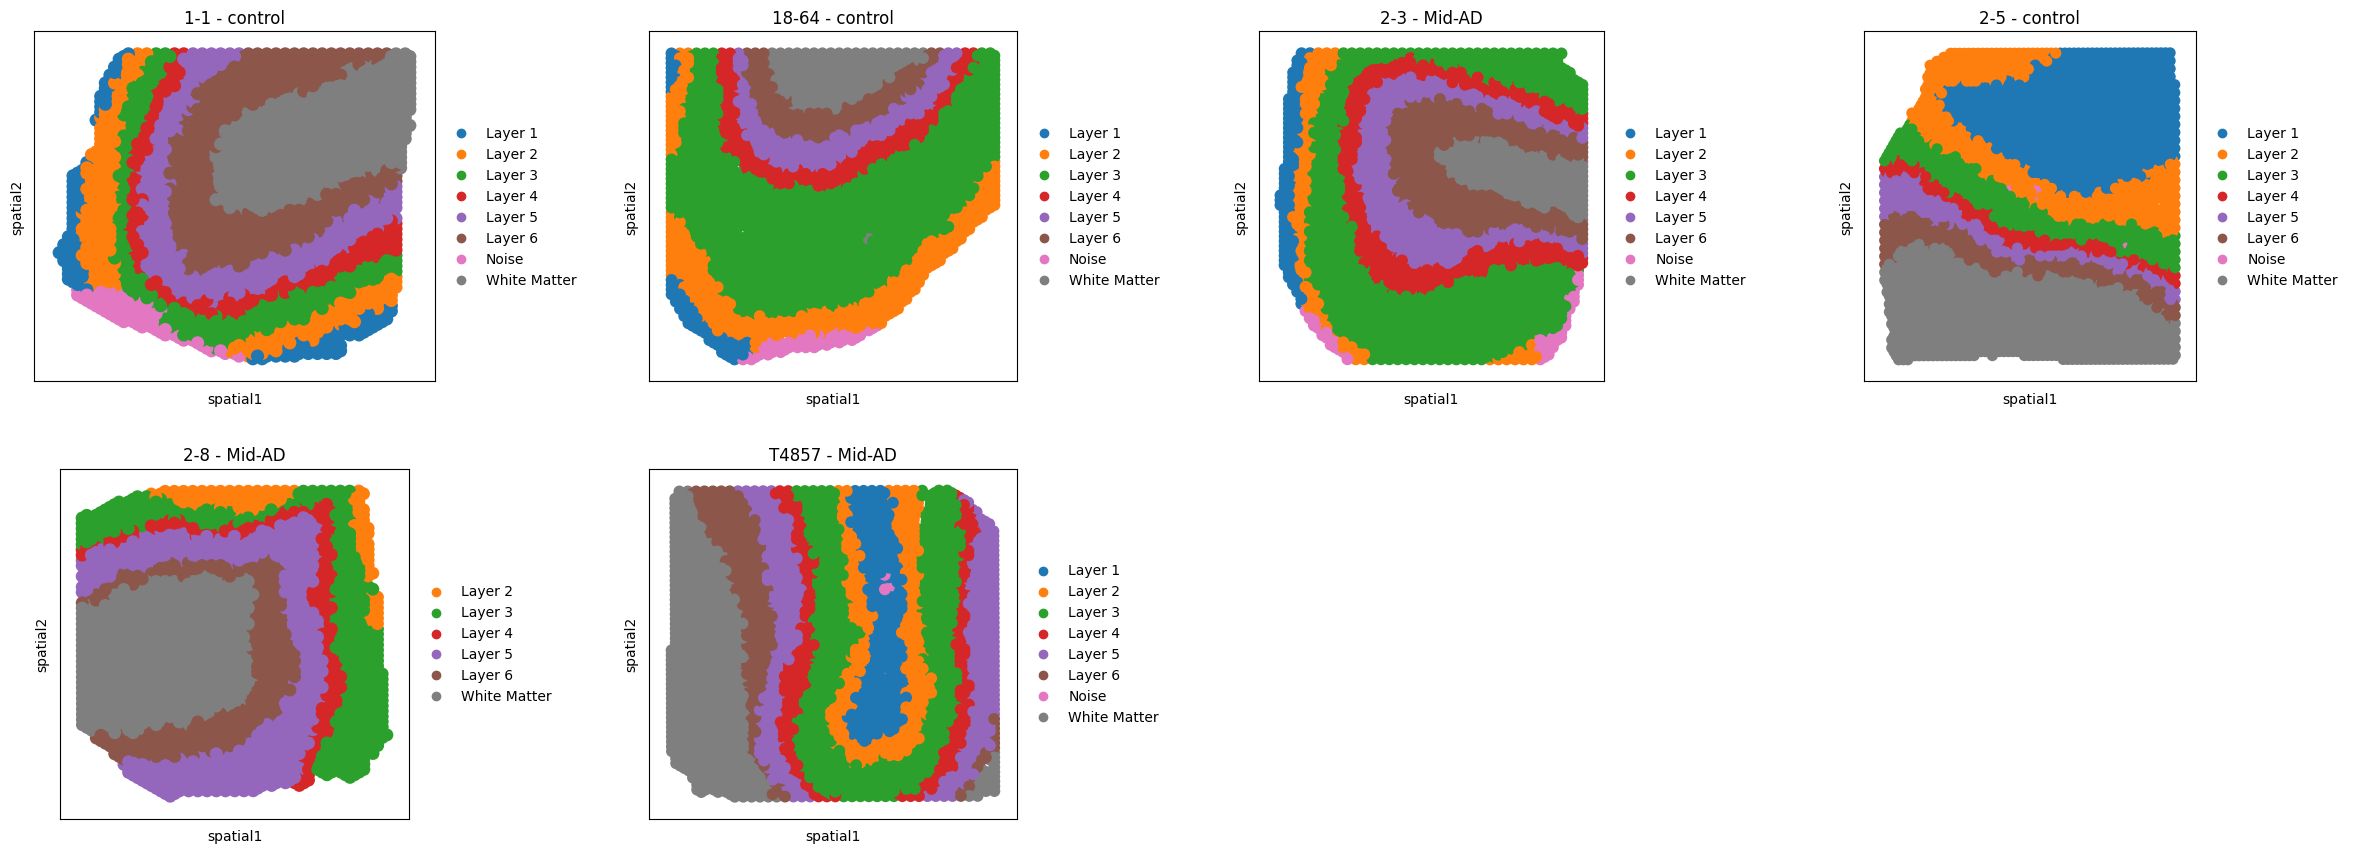

In [22]:
library_ids = list(adata.uns['spatial'].keys())
titles = [
    f"{pid} - {adata.obs.loc[adata.obs['patient_id'] == pid, 'stage'].iloc[0]}"
    for pid in library_ids
]

sq.pl.spatial_scatter(
    adata,
    spatial_key='spatial',
    library_key='patient_id', 
    color="Layer",
    size=10,
    img=False,
    title=titles
)

## 1. Normalization

The data needs to be normalized for InterScale. Check if the data is already normalized: 

In [23]:
print(f'Min count: {adata.X.min()}, Max count: {adata.X.max()}')

Min count: 0.0, Max count: 1461.0


The data is not yet normalized, so normalize and transform with log1p.

In [24]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

In [25]:
print(f'Min count: {adata.layers["log1p_norm"].min()}, Max count: {adata.layers["log1p_norm"].max()}')

Min count: 0.0, Max count: 7.954138278961182


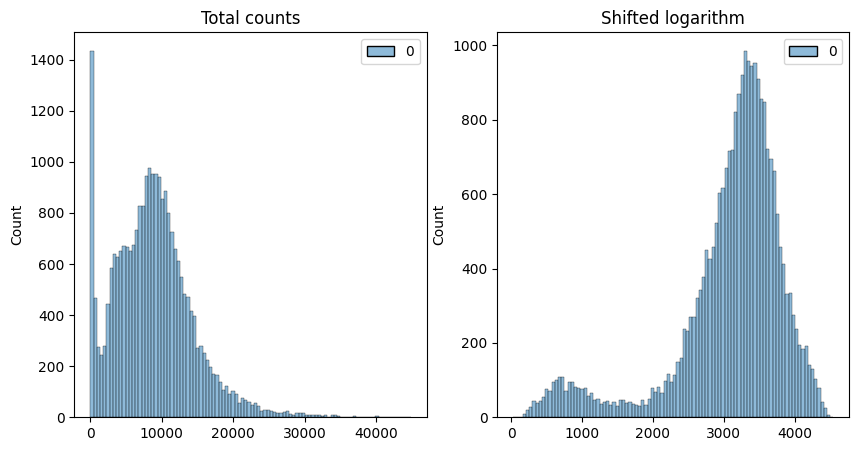

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.X.sum(1), bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

In [14]:
adata.layers['raw_counts'] = adata.X

In [15]:
# highly variable gene selection
sc.pp.highly_variable_genes(
    adata, flavor="seurat_v3", layer="raw_counts", n_top_genes=5000, subset=True
)

In [16]:
adata

AnnData object with n_obs × n_vars = 25048 × 5000
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region', 'patient_id', 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'category', 'stage', 'patientID', 'Layer', 'seurat_clusters', 'integrated_snn_res.0.17', 'count_mode', 'split', 'patientID_layer', 'sliding_window_assignment', 'globalX', 'globalY'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Layer_colors', 'sliding_window_assignment_colors', 'spatial', 'spatial_neighbors', 'spatialdata_attrs', 'hvg'
    obsm: 'spatial'
    layers: 'log1p_norm', 'raw_counts'
    obsp: 'spatial_connectivities', 'spatial_distances'

### Is there a reason for the bi-modal behaviour?

In [40]:
# Add a column marking which mode each cell belongs to
cutoff = 1500  # adjust based on your plot - looks like the valley is around 1500
adata.obs['count_mode'] = np.where(
    adata.layers["log1p_norm"].sum(1) < cutoff, 
    'low', 
    'high'
)

# Check the split
print(adata.obs['count_mode'].value_counts())

count_mode
high    23495
low      1798
Name: count, dtype: int64


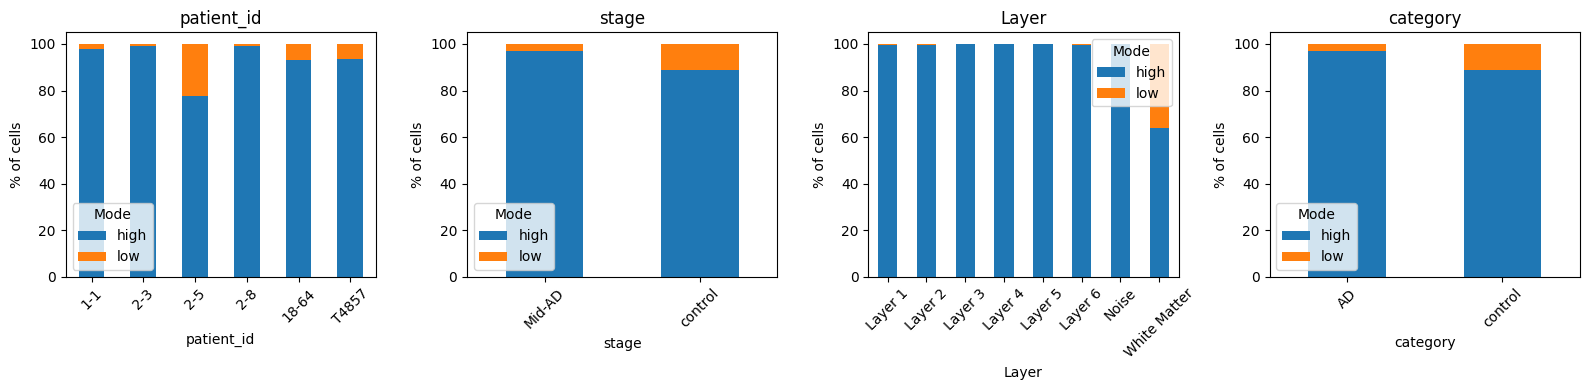

In [42]:
import pandas as pd

# List your categorical columns of interest
cat_cols = ['patient_id', 'stage', 'Layer']  # adjust to your .obs columns

fig, axes = plt.subplots(1, len(cat_cols), figsize=(4*len(cat_cols), 4))

for ax, col in zip(axes, cat_cols):
    # Cross-tabulation with percentages
    ct = pd.crosstab(adata.obs[col], adata.obs['count_mode'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'{col}')
    ax.set_ylabel('% of cells')
    ax.legend(title='Mode')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2. Calculate spatial connectivity matrix

Use [`squidpy.gr.spatial_neighbors()`](https://squidpy.readthedocs.io/en/stable/api/squidpy.gr.spatial_neighbors.html)) to calculate the spatial connectivity. For Visium it is important to set `coord_type='grid'` and indicate the IDs per slide (e.i. `patient_id`)

In [28]:
np.unique(adata.obs['patient_id'])

array(['1-1', '18-64', '2-3', '2-5', '2-8', 'T4857'], dtype=object)

In [29]:
sq.gr.spatial_neighbors(
    adata,
    coord_type = "grid",
    library_key = "patient_id"
)

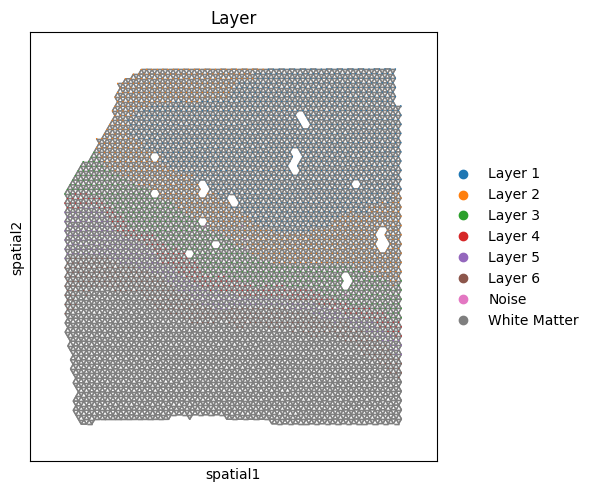

In [30]:
sq.pl.spatial_scatter(
    adata,
    library_key='patient_id',
    library_id = '2-5',
    connectivity_key="spatial_connectivities",
    img=False,
    color=["Layer"]
)

## 3. Optional: Calculate sliding windows

Sliding windows are necessary in case the tissue slide contains more than 4k cells. First, check how many cells are at minimum or maximum in your dataset.

In [31]:
tissue_cell_number = adata.obs.groupby('patient_id').size()
print(f"Nr cells per sliding window: Min: {tissue_cell_number.min()}, Max: {tissue_cell_number.max()}, Avg: {tissue_cell_number.mean()}")

Nr cells per sliding window: Min: 3445, Max: 4832, Avg: 4215.5


/tmp/ipykernel_3099425/2250730267.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_cell_number = adata.obs.groupby('patient_id').size()


<AxesSubplot: xlabel='patient_id'>

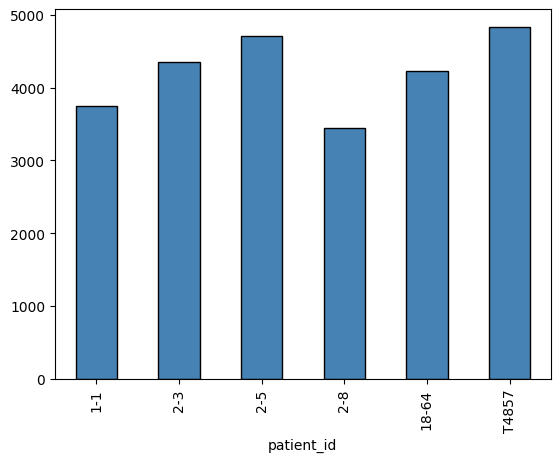

In [32]:
tissue_cell_number.plot(kind='bar', color='steelblue', edgecolor='black')

Instead of creating sliding windows we train per Brain Layer.

In [33]:
layer_cell_number = adata.obs.groupby(['patient_id', 'Layer']).size()
print(f"Nr cells per sliding window: Min: {tissue_cell_number.min()}, Max: {tissue_cell_number.max()}, Avg: {tissue_cell_number.mean()}")

Nr cells per sliding window: Min: 3445, Max: 4832, Avg: 4215.5


/tmp/ipykernel_3099425/3524630527.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  layer_cell_number = adata.obs.groupby(['patient_id', 'Layer']).size()


<AxesSubplot: xlabel='patient_id,Layer'>

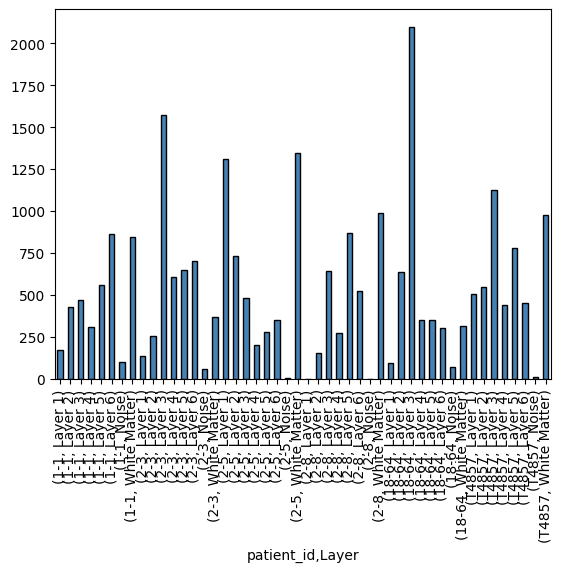

In [34]:
layer_cell_number.plot(kind='bar', color='steelblue', edgecolor='black')

In [35]:
# remove noise
nr_cells_before = len(adata.obs_names)
adata = adata[adata.obs['Layer'] != 'Noise']
nr_cells_now = len(adata.obs_names)
print(f'Cells removed: {nr_cells_before-nr_cells_now}')

Cells removed: 245


Create combined `patient_id` and layer label to use as `sample_id`. 

In [45]:
adata.obs['patientID_layer'] = adata.obs['patient_id'].astype(str) + '_' + adata.obs['Layer'].astype(str)
print(np.unique(adata.obs['patientID_layer']))

['1-1_Layer 1' '1-1_Layer 2' '1-1_Layer 3' '1-1_Layer 4' '1-1_Layer 5'
 '1-1_Layer 6' '1-1_White Matter' '18-64_Layer 1' '18-64_Layer 2'
 '18-64_Layer 3' '18-64_Layer 4' '18-64_Layer 5' '18-64_Layer 6'
 '18-64_White Matter' '2-3_Layer 1' '2-3_Layer 2' '2-3_Layer 3'
 '2-3_Layer 4' '2-3_Layer 5' '2-3_Layer 6' '2-3_White Matter'
 '2-5_Layer 1' '2-5_Layer 2' '2-5_Layer 3' '2-5_Layer 4' '2-5_Layer 5'
 '2-5_Layer 6' '2-5_White Matter' '2-8_Layer 2' '2-8_Layer 3'
 '2-8_Layer 4' '2-8_Layer 5' '2-8_Layer 6' '2-8_White Matter'
 'T4857_Layer 1' 'T4857_Layer 2' 'T4857_Layer 3' 'T4857_Layer 4'
 'T4857_Layer 5' 'T4857_Layer 6' 'T4857_White Matter']


/usr/local/lib/python3.10/dist-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]


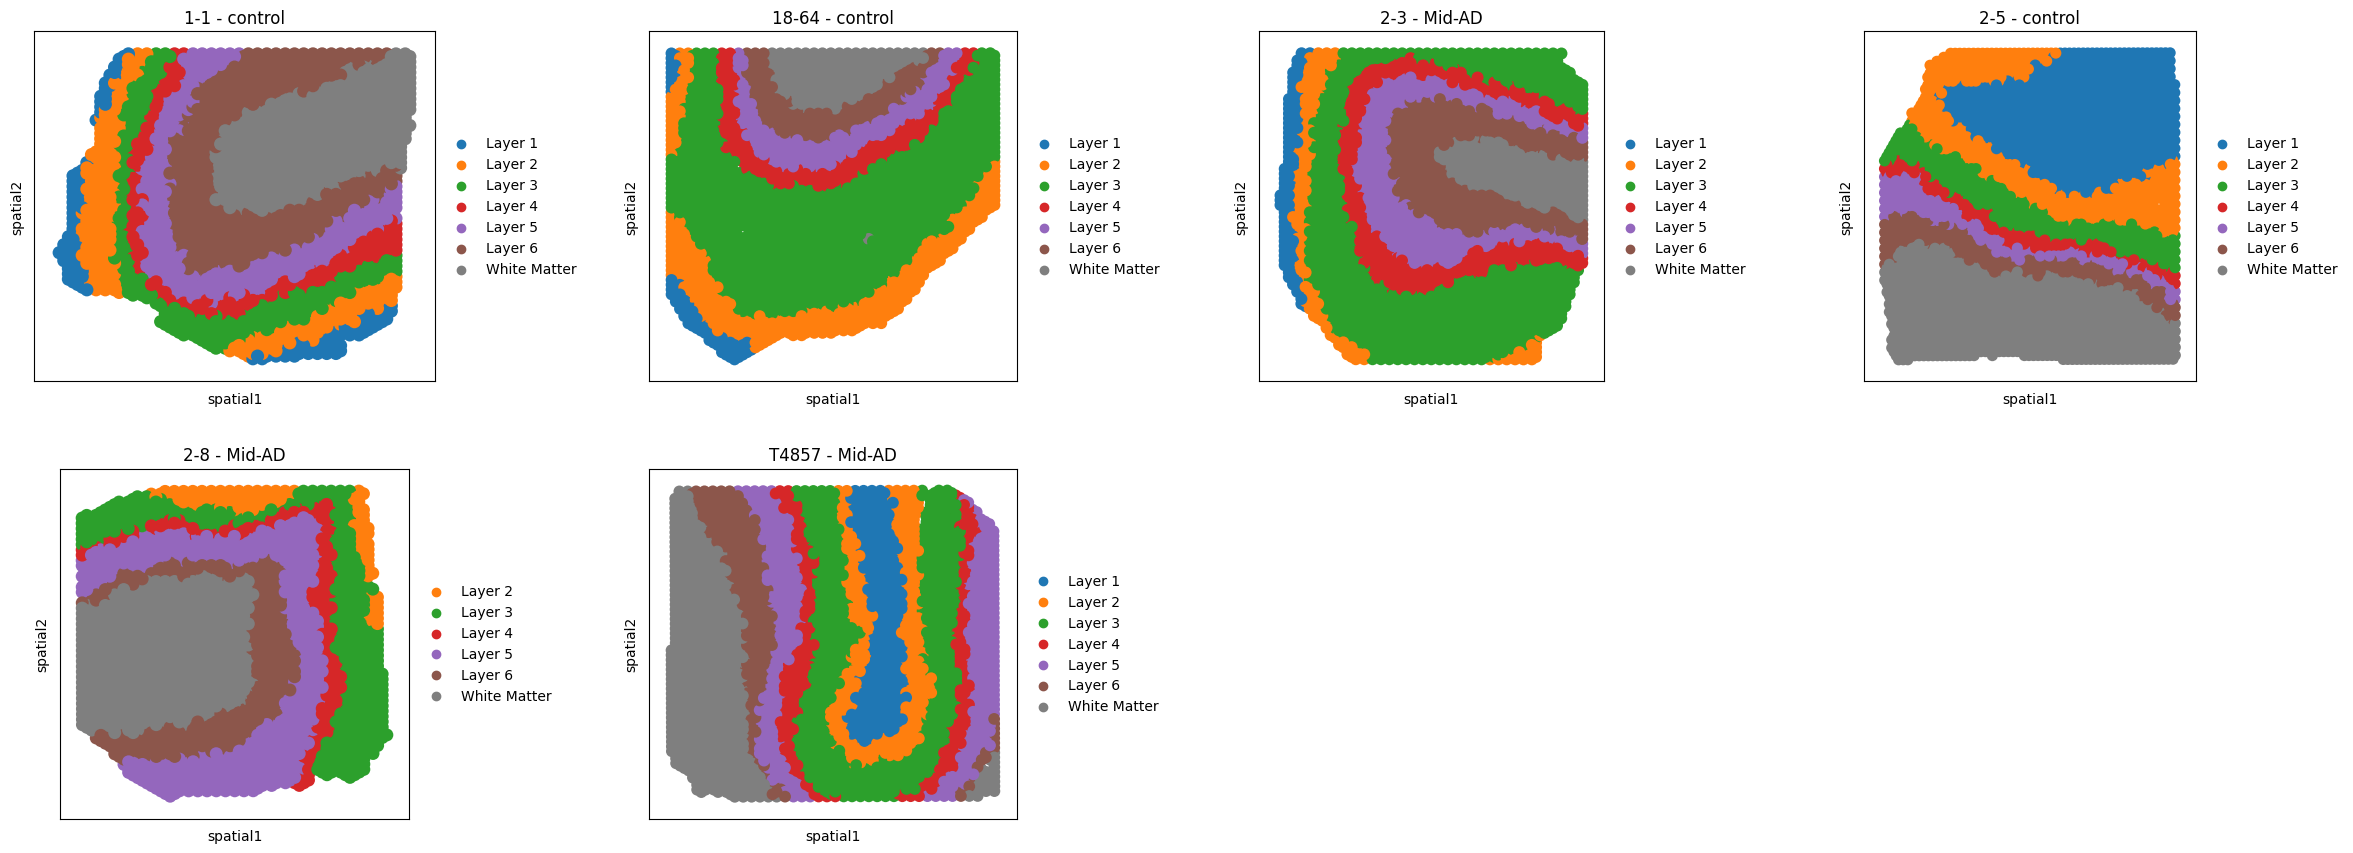

In [36]:
# Plot to see if it still makes sense
sq.pl.spatial_scatter(
    adata,
    spatial_key='spatial',
    library_key='patient_id', 
    color="Layer",
    size=10,
    img=False,
    title=titles
)

In addition to having the layers as `sample_id` to use as batch label we now also calculate sliding windows to split the data. 

In [91]:
sliding_window(adata, 
                   library_key = 'patient_id', 
                    partial_windows = "split",
                  window_size = 100, 
                  max_nr_cells = 2000, 
                   sliding_window_key = f"sliding_window_assignment"
                  )

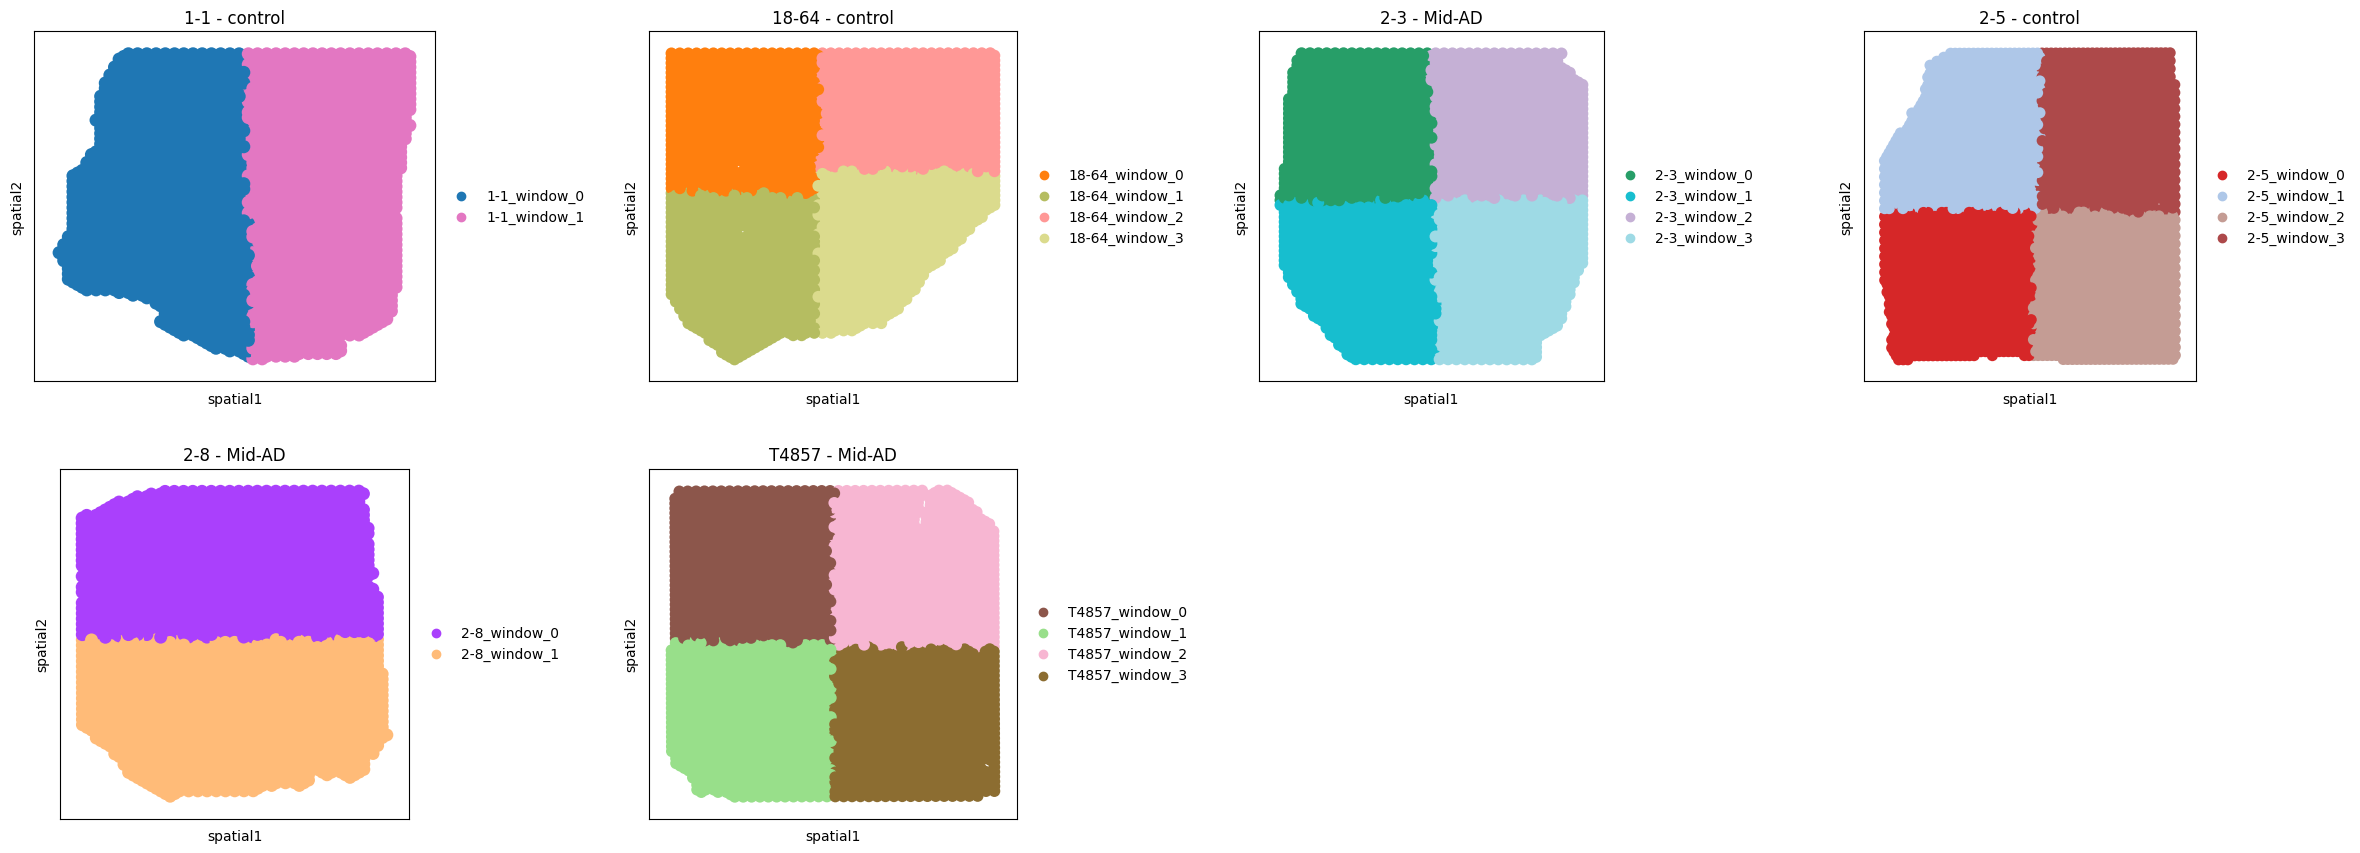

In [92]:
# Plot to see if it still makes sense
sq.pl.spatial_scatter(
    adata,
    spatial_key='spatial',
    library_key='patient_id', 
    color="sliding_window_assignment",
    size=10,
    img=False,
    title=titles
)

In [93]:
layer_cell_number = adata.obs.groupby(['sliding_window_assignment']).size()
print(f"Nr cells per sliding window: Min: {tissue_cell_number.min()}, Max: {tissue_cell_number.max()}, Avg: {tissue_cell_number.mean()}")

Nr cells per sliding window: Min: 3445, Max: 4832, Avg: 4215.5


/tmp/ipykernel_3099425/429298005.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  layer_cell_number = adata.obs.groupby(['sliding_window_assignment']).size()


We observe that there are a slides with only a few cells but 2 slides with more than 4k cells. For this case we have the option to 1) increase the context length to max = 4875 or 2) calculate sliding windows for all slides that have more than 3k cells. 

With the sliding windows the maximum number of cells per sliding window is `2099`. 

<mark>TODO: Adjust max_seq_len in config file!</mark>
Given this we adjust the `max_seq_len` from the model.global_component to `2099`. The default is `2000`.

## 4. Split data into train and val set

Training the model requires a `split` assignment for each donor/patient/sliding window that you wanna train on. 

In [37]:
import numpy as np
from sklearn.model_selection import train_test_split

In [38]:
split_map = {
    '1-1': 'train', '2-3': 'train',
    '18-64': 'val', '2-8': 'val',
    '2-5': 'test', 'T4857': 'test'
}
adata.obs['split'] = adata.obs['patient_id'].map(split_map)

In [21]:
split_map_1 = {
    '1-1': 'val', '2-3': 'train',
    '18-64': 'train', '2-8': 'val',
    '2-5': 'test', 'T4857': 'test'
}
adata.obs['split_1'] = adata.obs['patient_id'].map(split_map_1)

## Save adata object

Save the prepared adata object such that it can be loaded for the model training. 

In [22]:
adata.write('/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/data/chen_adata_pp.h5ad')

## Prepare config file

Duplicate the minum requirement config file from `/GT-long-range-niches/src/config_files/InterScale_example.yaml` and add the necessary specification for the Visum data:

```
model:
  local_component:
    name: GCN
  global_component:
    name: self-attn-transformer
        max_seq_len: 2099
  save: /path/to/save/model/
dataset:
  h5ad_data: chen_adata_pp.h5ad
  name: Visium_chen_22
  sample_key: ['patient_id']
  spatial_neigbors_kwargs:
    coord_type: grid
    library_key: patient_id
```


Save the config file as `.yaml` and proceed to training (either interactively in jupyter notebook or by running a script).

In [18]:
adata = sc.read_h5ad(os.path.join(BASE_DIR_PROJECT, 'data/chen_adata_pp.h5ad'))
adata

AnnData object with n_obs × n_vars = 25048 × 5000
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region', 'patient_id', 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'category', 'stage', 'patientID', 'Layer', 'seurat_clusters', 'integrated_snn_res.0.17', 'count_mode', 'split', 'patientID_layer', 'sliding_window_assignment', 'globalX', 'globalY'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Layer_colors', 'hvg', 'sliding_window_assignment_colors', 'spatial', 'spatial_neighbors', 'spatialdata_attrs'
    obsm: 'spatial'
    layers: 'log1p_norm', 'raw_counts'
    obsp: 'spatial_connectivities', 'spatial_distances'